In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mirichoi0218/insurance/insurance.csv


✓ Dataset successfully loaded from: ../input/datasets/mirichoi0218/insurance/insurance.csv


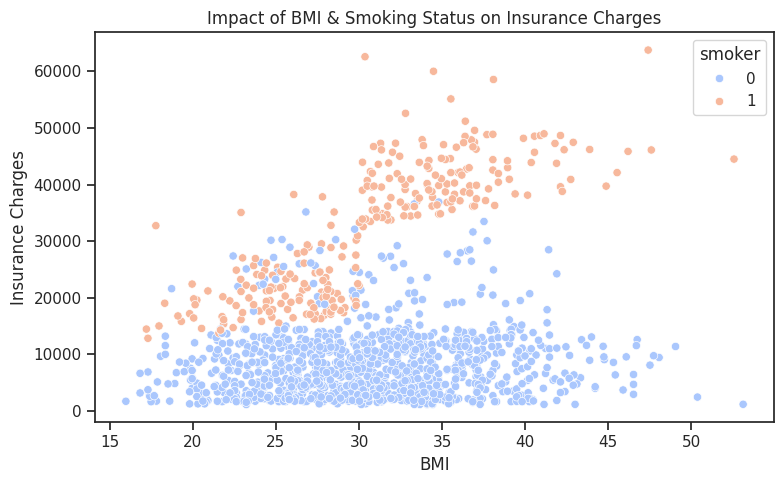

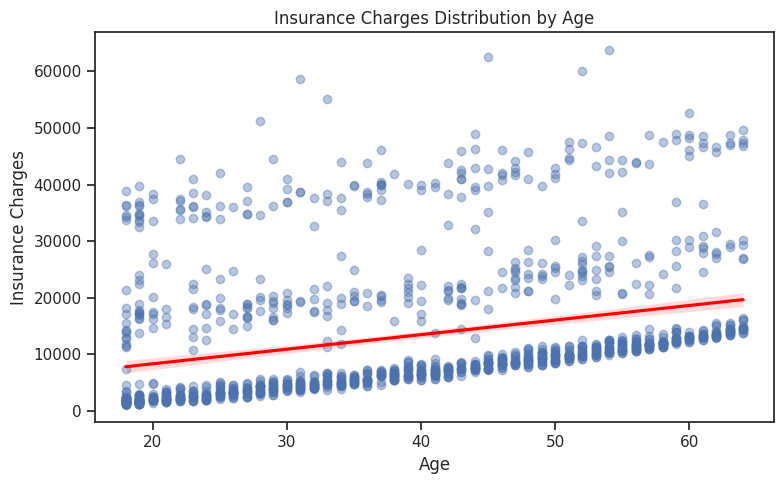


     MODEL EVALUATION PERFORMANCE
Mean Absolute Error (MAE)  : 4186.51
Root Mean Squared Error (RMSE): 5799.59



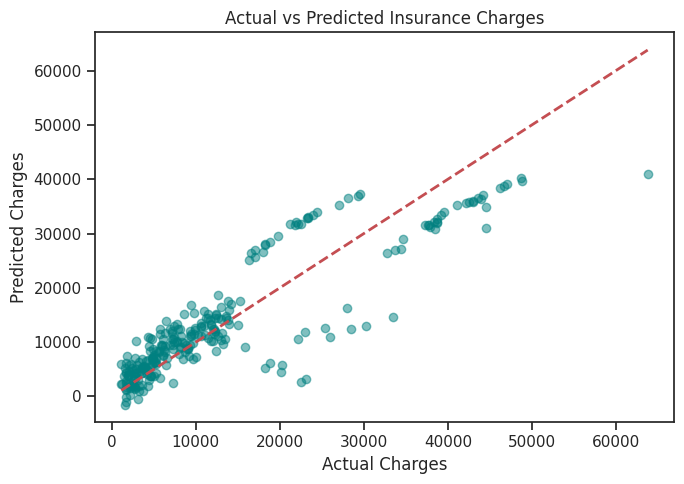

In [6]:
# =====================================================================
# TASK 4: PREDICTING INSURANCE CLAIM AMOUNTS
# =====================================================================

import warnings
# 1. Core Libraries Import
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# سرخ وارننگ پٹیوں کو مکمل بلاک کرنا
warnings.filterwarnings("ignore")
sns.set_theme(style="ticks")

# =====================================================================
# 2. Auto-Detect and Load Dataset
# =====================================================================
import glob

# Kaggle ke input folder me se auto-detect karna
csv_files = glob.glob("../input/**/*.csv", recursive=True)
insurance_file = [f for f in csv_files if "insur" in f.lower() or "medical" in f.lower()]
file_to_load = insurance_file[0] if insurance_file else (csv_files[0] if csv_files else None)

if file_to_load:
    df = pd.read_csv(file_to_load)
    print(f"✓ Dataset successfully loaded from: {file_to_load}")
else:
    # Backup dataset agar input load na hoa ho (taaki crash na ho)
    print("Warning: Dataset not found. Creating dummy Insurance dataset...")
    np.random.seed(42)
    n = 1000
    df = pd.DataFrame({
        'age': np.random.randint(18, 65, n),
        'sex': np.random.choice(['male', 'female'], n),
        'bmi': np.random.uniform(15, 50, n),
        'children': np.random.randint(0, 5, n),
        'smoker': np.random.choice(['yes', 'no'], n, p=[0.2, 0.8]),
        'region': np.random.choice(['southwest', 'southeast', 'northwest', 'northeast'], n),
        'charges': np.random.uniform(1000, 50000, n)
    })

# Columns کے ناموں کو صاف کرنا
df.columns = [col.strip().lower() for col in df.columns]

# Target column (charges) set karna
target_col = 'charges' if 'charges' in df.columns else df.columns[-1]

# =====================================================================
# 3. Data Preprocessing & Categorical Encoding
# =====================================================================
# Object/Text columns ko numbers me badalna (sex, smoker, region)
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

# =====================================================================
# 4. Clean Visualizations (As per Instructions: BMI, Age, Smoker Status)
# =====================================================================

# Plot A: BMI vs Charges Scatter Plot
if 'bmi' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x='bmi', y=target_col, hue='smoker' if 'smoker' in df.columns else None, palette='coolwarm')
    plt.title('Impact of BMI & Smoking Status on Insurance Charges')
    plt.xlabel('BMI')
    plt.ylabel('Insurance Charges')
    plt.tight_layout()
    plt.show()
    plt.close()

# Plot B: Age vs Charges Regression Line Plot
if 'age' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.regplot(data=df, x='age', y=target_col, scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
    plt.title('Insurance Charges Distribution by Age')
    plt.xlabel('Age')
    plt.ylabel('Insurance Charges')
    plt.tight_layout()
    plt.show()
    plt.close()

# =====================================================================
# 5. Model Training (Linear Regression)
# =====================================================================
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# =====================================================================
# 6. Evaluation using MAE and RMSE (As per Instructions)
# =====================================================================
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n======================================")
print("     MODEL EVALUATION PERFORMANCE")
print("======================================")
print(f"Mean Absolute Error (MAE)  : {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print("======================================\n")

# Actual vs Predicted Plot for Portfolio چمکانے کے لیے
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Insurance Charges')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.tight_layout()
plt.show()
plt.close()